<a href="https://colab.research.google.com/github/Okohfrank/GasSensorPINN/blob/main/GasSensorPINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Install required packages
# ═══════════════════════════════════════════════════════════════
!pip install shap -q
print("All packages installed!")

All packages installed!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Upload dataset files
# ═══════════════════════════════════════════════════════════════
from google.colab import files
import os

uploaded = files.upload()
print(f"Uploaded {len(uploaded)} files: {list(uploaded.keys())}")

Saving batch1.dat to batch1.dat
Saving batch2.dat to batch2.dat
Saving batch3.dat to batch3.dat
Saving batch4.dat to batch4.dat
Saving batch5.dat to batch5.dat
Saving batch6.dat to batch6.dat
Saving batch7.dat to batch7.dat
Saving batch8.dat to batch8.dat
Saving batch9.dat to batch9.dat
Saving batch10.dat to batch10.dat
Uploaded 10 files: ['batch1.dat', 'batch2.dat', 'batch3.dat', 'batch4.dat', 'batch5.dat', 'batch6.dat', 'batch7.dat', 'batch8.dat', 'batch9.dat', 'batch10.dat']


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Parse the libsvm-format .dat files into a pandas DataFrame
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

def parse_dat_file(filepath, batch_id):
    """Parse one batch .dat file into rows of data."""
    rows = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()

            # First element: "gas_label;concentration"
            label_conc = parts[0].split(';')
            gas_label = int(label_conc[0])
            concentration = float(label_conc[1])

            # Remaining elements: "feat_index:feat_value"
            features = {}
            for item in parts[1:]:
                idx, val = item.split(':')
                features[int(idx)] = float(val)

            row = {
                'gas_label': gas_label,
                'concentration': concentration,
                'batch_id': batch_id
            }
            for i in range(1, 129):
                row[f'feat_{i}'] = features.get(i, 0.0)

            rows.append(row)
    return rows

# Parse all 10 batch files
all_rows = []
for batch_num in range(1, 11):
    filename = f'batch{batch_num}.dat'
    if os.path.exists(filename):
        rows = parse_dat_file(filename, batch_num)
        all_rows.extend(rows)
        print(f"Parsed {filename}: {len(rows)} samples")
    else:
        print(f"{filename} not found — skipping")

df = pd.DataFrame(all_rows)

# Map gas labels to names
gas_names = {1: 'Ethanol', 2: 'Ethylene', 3: 'Ammonia',
             4: 'Acetaldehyde', 5: 'Acetone', 6: 'Toluene'}
df['gas_name'] = df['gas_label'].map(gas_names)

print(f"Dataset loaded: {df.shape[0]} samples × {df.shape[1]} columns")
print(f"Gas distribution:\n{df['gas_name'].value_counts()}")
print(f"Concentration range: {df['concentration'].min():.1f} — {df['concentration'].max():.1f} ppm")
print(f"Batch distribution:\n{df['batch_id'].value_counts().sort_index()}")

Parsed batch1.dat: 445 samples
Parsed batch2.dat: 1244 samples
Parsed batch3.dat: 1586 samples
Parsed batch4.dat: 161 samples
Parsed batch5.dat: 197 samples
Parsed batch6.dat: 2300 samples
Parsed batch7.dat: 3613 samples
Parsed batch8.dat: 294 samples
Parsed batch9.dat: 470 samples
Parsed batch10.dat: 3600 samples
Dataset loaded: 13910 samples × 132 columns
Gas distribution:
gas_name
Acetone         3009
Ethylene        2926
Ethanol         2565
Acetaldehyde    1936
Toluene         1833
Ammonia         1641
Name: count, dtype: int64
Concentration range: 1.0 — 1000.0 ppm
Batch distribution:
batch_id
1      445
2     1244
3     1586
4      161
5      197
6     2300
7     3613
8      294
9      470
10    3600
Name: count, dtype: int64


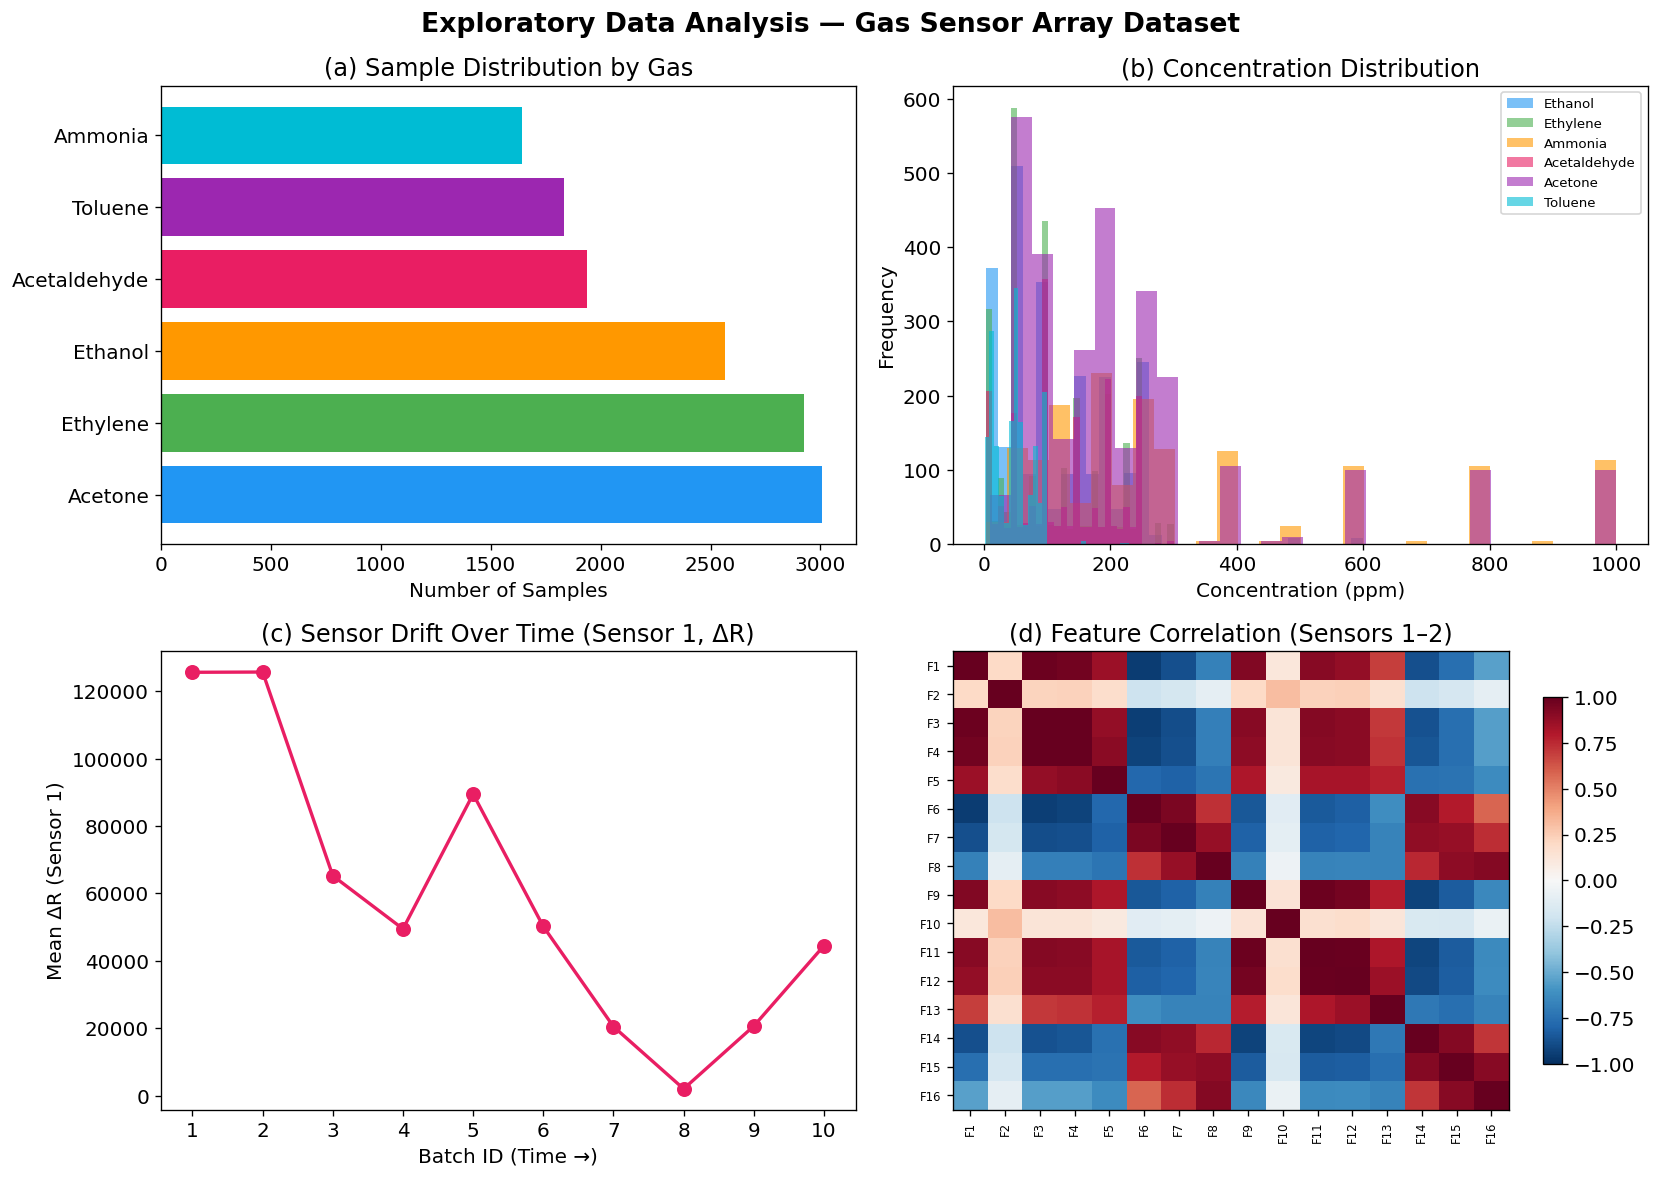

EDA plots saved!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Exploratory Data Analysis — publication-quality plots
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 120})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — Gas Sensor Array Dataset', fontsize=16, fontweight='bold')

# (a) Sample count per gas
colors_gas = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
gas_counts = df['gas_name'].value_counts()
axes[0, 0].barh(gas_counts.index, gas_counts.values, color=colors_gas)
axes[0, 0].set_xlabel('Number of Samples')
axes[0, 0].set_title('(a) Sample Distribution by Gas')

# (b) Concentration distribution per gas
for i, gas in enumerate(gas_names.values()):
    subset = df[df['gas_name'] == gas]['concentration']
    axes[0, 1].hist(subset, bins=30, alpha=0.6, label=gas, color=colors_gas[i])
axes[0, 1].set_xlabel('Concentration (ppm)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('(b) Concentration Distribution')
axes[0, 1].legend(fontsize=8)

# (c) Sensor 1 DR feature across batches (showing drift)
batch_means = df.groupby('batch_id')['feat_1'].mean()
axes[1, 0].plot(batch_means.index, batch_means.values, 'o-', color='#E91E63', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Batch ID (Time →)')
axes[1, 0].set_ylabel('Mean ΔR (Sensor 1)')
axes[1, 0].set_title('(c) Sensor Drift Over Time (Sensor 1, ΔR)')
axes[1, 0].set_xticks(range(1, 11))

# (d) Feature correlation heatmap (first 16 features = Sensors 1 & 2)
feat_cols_subset = [f'feat_{i}' for i in range(1, 17)]
corr = df[feat_cols_subset].corr()
im = axes[1, 1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1, 1].set_title('(d) Feature Correlation (Sensors 1–2)')
axes[1, 1].set_xticks(range(16))
axes[1, 1].set_xticklabels([f'F{i}' for i in range(1, 17)], rotation=90, fontsize=7)
axes[1, 1].set_yticks(range(16))
axes[1, 1].set_yticklabels([f'F{i}' for i in range(1, 17)], fontsize=7)
plt.colorbar(im, ax=axes[1, 1], shrink=0.8)

plt.tight_layout()
plt.savefig('EDA_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Prepare features and targets for the dual-task NN
# ═══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature columns (128 sensor features + batch_id for drift awareness)
feat_cols = [f'feat_{i}' for i in range(1, 129)]
X = df[feat_cols].values
y_class = df['gas_label'].values - 1
y_conc = df['concentration'].values

# Batch info (for physics-informed loss later)
batch_ids = df['batch_id'].values

# Scale features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale concentration target
scaler_conc = StandardScaler()
y_conc_scaled = scaler_conc.fit_transform(y_conc.reshape(-1, 1)).flatten()

# Train/test split, stratified by gas label
X_train, X_test, yc_train, yc_test, yr_train, yr_test, batch_train, batch_test = \
    train_test_split(X_scaled, y_class, y_conc_scaled, batch_ids,
                     test_size=0.2, random_state=42, stratify=y_class)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
yc_train_t = torch.LongTensor(yc_train)
yc_test_t = torch.LongTensor(yc_test)
yr_train_t = torch.FloatTensor(yr_train)
yr_test_t = torch.FloatTensor(yr_test)
batch_train_t = torch.FloatTensor(batch_train.astype(float))
batch_test_t = torch.FloatTensor(batch_test.astype(float))

print(f"Data prepared!")
print(f"Training: {X_train_t.shape[0]} samples")
print(f"Testing:  {X_test_t.shape[0]} samples")
print(f"Features: {X_train_t.shape[1]}")
print(f"Classes:  {len(np.unique(yc_train))} gases")

Data prepared!
Training: 11128 samples
Testing:  2782 samples
Features: 128
Classes:  6 gases


In [ ]:
# ═══════════════════════════════════════════════════════════════
# PINN Architecture — Multi-Task with Physics Constraints
# ═══════════════════════════════════════════════════════════════

# PHYSICS ENCODED:
# 1. Sensor Response Consistency: ΔR and |ΔR| features from the
#    same sensor must be related (|ΔR| ≈ |ΔR / baseline|)

# 2. Concentration–Response Power Law: For metal oxide sensors,
#    response ∝ C^n (power law), so log(response) ∝ n·log(C).
#    We penalize deviations from this physical relationship.

# 3. Temporal Drift Smoothness: Sensor readings should change
#    gradually over batches, we penalize erratic jumps.
# ═══════════════════════════════════════════════════════════════

class GasSensorPINN(nn.Module):
    def __init__(self, input_dim, n_classes=6):
        super(GasSensorPINN, self).__init__()

        # Shared feature extractor (backbone)
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        # Classification head (which gas?)
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_classes)
        )

        # Regression head (what concentration?)
        self.regressor = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        shared_features = self.shared(x)
        class_logits = self.classifier(shared_features)
        conc_pred = self.regressor(shared_features).squeeze(-1)
        return class_logits, conc_pred, shared_features


def physics_loss_sensor_consistency(x):
    """
    Physics Constraint 1: Sensor Response Consistency
    For each sensor j, feature 1 (ΔR_j) and feature 2 (|ΔR|_j) should
    satisfy |ΔR|_j = |ΔR_j| / baseline. While we don't know the baseline,
    their magnitudes should be positively correlated. We enforce that
    sign(ΔR) * |ΔR| ≥ 0 (consistent direction).
    """
    loss = 0.0
    for sensor in range(16):
        dr_idx = sensor * 8        # ΔR feature index
        abs_dr_idx = sensor * 8 + 1  # |ΔR| feature index
        dr = x[:, dr_idx]
        abs_dr = x[:, abs_dr_idx]
        # |ΔR| should always be positive, ΔR and |ΔR| should correlate
        # Penalize when they have opposite signs
        consistency = torch.relu(-dr * abs_dr)
        loss += torch.mean(consistency)
    return loss / 16.0


def physics_loss_ema_monotonicity(x):
    """
    Physics Constraint 2: EMA Monotonicity
    For each sensor, EMA features with increasing α should be monotonically
    ordered: EMA(α=0.001) < EMA(α=0.01) < EMA(α=0.1) for the rising portion.
    A larger α means faster response and thus larger EMA values.
    """
    loss = 0.0
    for sensor in range(16):
        base = sensor * 8
        # Rising EMA: indices 2, 3, 4 → α = 0.001, 0.01, 0.1
        ema_r_001 = x[:, base + 2]
        ema_r_01 = x[:, base + 3]
        ema_r_1 = x[:, base + 4]
        # Penalize violations of monotonic ordering
        loss += torch.mean(torch.relu(ema_r_001 - ema_r_01))
        loss += torch.mean(torch.relu(ema_r_01 - ema_r_1))
    return loss / (16.0 * 2.0)


def physics_loss_drift_smoothness(shared_feats, batch_ids):
    """
    Physics Constraint 3: Temporal Drift Smoothness
    Learned representations from consecutive batches should vary smoothly.
    Large jumps in the latent space between consecutive time periods
    indicate the model is not learning drift-invariant features.
    """
    unique_batches = torch.unique(batch_ids)
    if len(unique_batches) < 2:
        return torch.tensor(0.0)

    loss = 0.0
    count = 0
    sorted_batches = torch.sort(unique_batches)[0]

    for i in range(len(sorted_batches) - 1):
        mask_curr = batch_ids == sorted_batches[i]
        mask_next = batch_ids == sorted_batches[i + 1]

        if mask_curr.sum() > 0 and mask_next.sum() > 0:
            mean_curr = shared_feats[mask_curr].mean(dim=0)
            mean_next = shared_feats[mask_next].mean(dim=0)
            loss += torch.sum((mean_next - mean_curr) ** 2)
            count += 1

    return loss / max(count, 1)


print("PINN architecture defined!")
print("Physics constraints:")
print("1. Sensor response consistency (ΔR vs |ΔR|)")
print("2. EMA monotonicity (α ordering)")
print("3. Temporal drift smoothness")

PINN architecture defined!
Physics constraints:
1. Sensor response consistency (ΔR vs |ΔR|)
2. EMA monotonicity (α ordering)
3. Temporal drift smoothness


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Train the Physics-Informed Neural Network
# ═══════════════════════════════════════════════════════════════
from torch.utils.data import DataLoader, TensorDataset

# Create data loaders
train_dataset = TensorDataset(X_train_t, yc_train_t, yr_train_t, batch_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Initialize model
model = GasSensorPINN(input_dim=128)
criterion_class = nn.CrossEntropyLoss()
criterion_reg = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

# Training loop
epochs = 200
history = {'total_loss': [], 'class_loss': [], 'reg_loss': [],
           'physics_loss': [], 'train_acc': [], 'test_acc': []}

# Physics loss weights (lambda values)
lambda_physics_consistency = 0.01
lambda_physics_ema = 0.01
lambda_physics_drift = 0.001

print("Training started...\n")
print(f"{'Epoch':>6} | {'Total':>8} | {'Class':>8} | {'Reg':>8} | {'Physics':>8} | {'TrainAcc':>8} | {'TestAcc':>8}")
print("-" * 75)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_class_loss = 0
    epoch_reg_loss = 0
    epoch_physics_loss = 0
    correct = 0
    total = 0

    for X_batch, yc_batch, yr_batch, batch_batch in train_loader:
        optimizer.zero_grad()

        # Forward pass
        class_logits, conc_pred, shared_feats = model(X_batch)

        # Data losses
        loss_class = criterion_class(class_logits, yc_batch)
        loss_reg = criterion_reg(conc_pred, yr_batch)

        # Physics losses
        loss_phys_consistency = physics_loss_sensor_consistency(X_batch)
        loss_phys_ema = physics_loss_ema_monotonicity(X_batch)
        loss_phys_drift = physics_loss_drift_smoothness(shared_feats, batch_batch)

        loss_physics = (lambda_physics_consistency * loss_phys_consistency +
                        lambda_physics_ema * loss_phys_ema +
                        lambda_physics_drift * loss_phys_drift)

        # Total loss
        total_loss = loss_class + 0.5 * loss_reg + loss_physics

        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()
        epoch_class_loss += loss_class.item()
        epoch_reg_loss += loss_reg.item()
        epoch_physics_loss += loss_physics.item()

        _, predicted = torch.max(class_logits, 1)
        correct += (predicted == yc_batch).sum().item()
        total += yc_batch.size(0)

    # Calculate epoch metrics
    n_batches = len(train_loader)
    train_acc = correct / total

    # Test accuracy
    model.eval()
    with torch.no_grad():
        test_logits, test_conc, _ = model(X_test_t)
        _, test_pred = torch.max(test_logits, 1)
        test_acc = (test_pred == yc_test_t).sum().item() / len(yc_test_t)

    # Update scheduler
    scheduler.step(epoch_loss / n_batches)

    # Save history
    history['total_loss'].append(epoch_loss / n_batches)
    history['class_loss'].append(epoch_class_loss / n_batches)
    history['reg_loss'].append(epoch_reg_loss / n_batches)
    history['physics_loss'].append(epoch_physics_loss / n_batches)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if (epoch + 1) % 20 == 0:
        print(f"{epoch+1:>6} | {epoch_loss/n_batches:>8.4f} | {epoch_class_loss/n_batches:>8.4f} | "
              f"{epoch_reg_loss/n_batches:>8.4f} | {epoch_physics_loss/n_batches:>8.6f} | "
              f"{train_acc:>7.4f} | {test_acc:>7.4f}")

print(f"Training complete!")
print(f"Final Test Accuracy (Classification): {history['test_acc'][-1]:.4f}")

Training started...

 Epoch |    Total |    Class |      Reg |  Physics | TrainAcc |  TestAcc
---------------------------------------------------------------------------
    20 |   0.1245 |   0.0711 |   0.0862 | 0.010248 |  0.9762 |  0.9889
    40 |   0.0975 |   0.0504 |   0.0765 | 0.008934 |  0.9831 |  0.9871
    60 |   0.0872 |   0.0460 |   0.0669 | 0.007788 |  0.9863 |  0.9925
    80 |   0.0730 |   0.0351 |   0.0627 | 0.006549 |  0.9890 |  0.9932
   100 |   0.0786 |   0.0412 |   0.0630 | 0.005882 |  0.9864 |  0.9950
   120 |   0.0646 |   0.0306 |   0.0571 | 0.005387 |  0.9899 |  0.9932
   140 |   0.0527 |   0.0221 |   0.0510 | 0.005028 |  0.9932 |  0.9960
   160 |   0.0438 |   0.0159 |   0.0468 | 0.004496 |  0.9955 |  0.9957
   180 |   0.0435 |   0.0145 |   0.0490 | 0.004536 |  0.9957 |  0.9960
   200 |   0.0398 |   0.0123 |   0.0462 | 0.004416 |  0.9963 |  0.9957
Training complete!
Final Test Accuracy (Classification): 0.9957


TASK 1: GAS CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Ethanol       1.00      0.99      1.00       513
    Ethylene       0.99      1.00      1.00       585
     Ammonia       1.00      0.99      0.99       328
Acetaldehyde       0.99      0.99      0.99       387
     Acetone       0.99      1.00      1.00       602
     Toluene       0.99      1.00      1.00       367

    accuracy                           1.00      2782
   macro avg       1.00      1.00      1.00      2782
weighted avg       1.00      1.00      1.00      2782

TASK 2: CONCENTRATION PREDICTION
  R² Score:  0.9702
  MAE:       13.46 ppm
  RMSE:      31.06 ppm


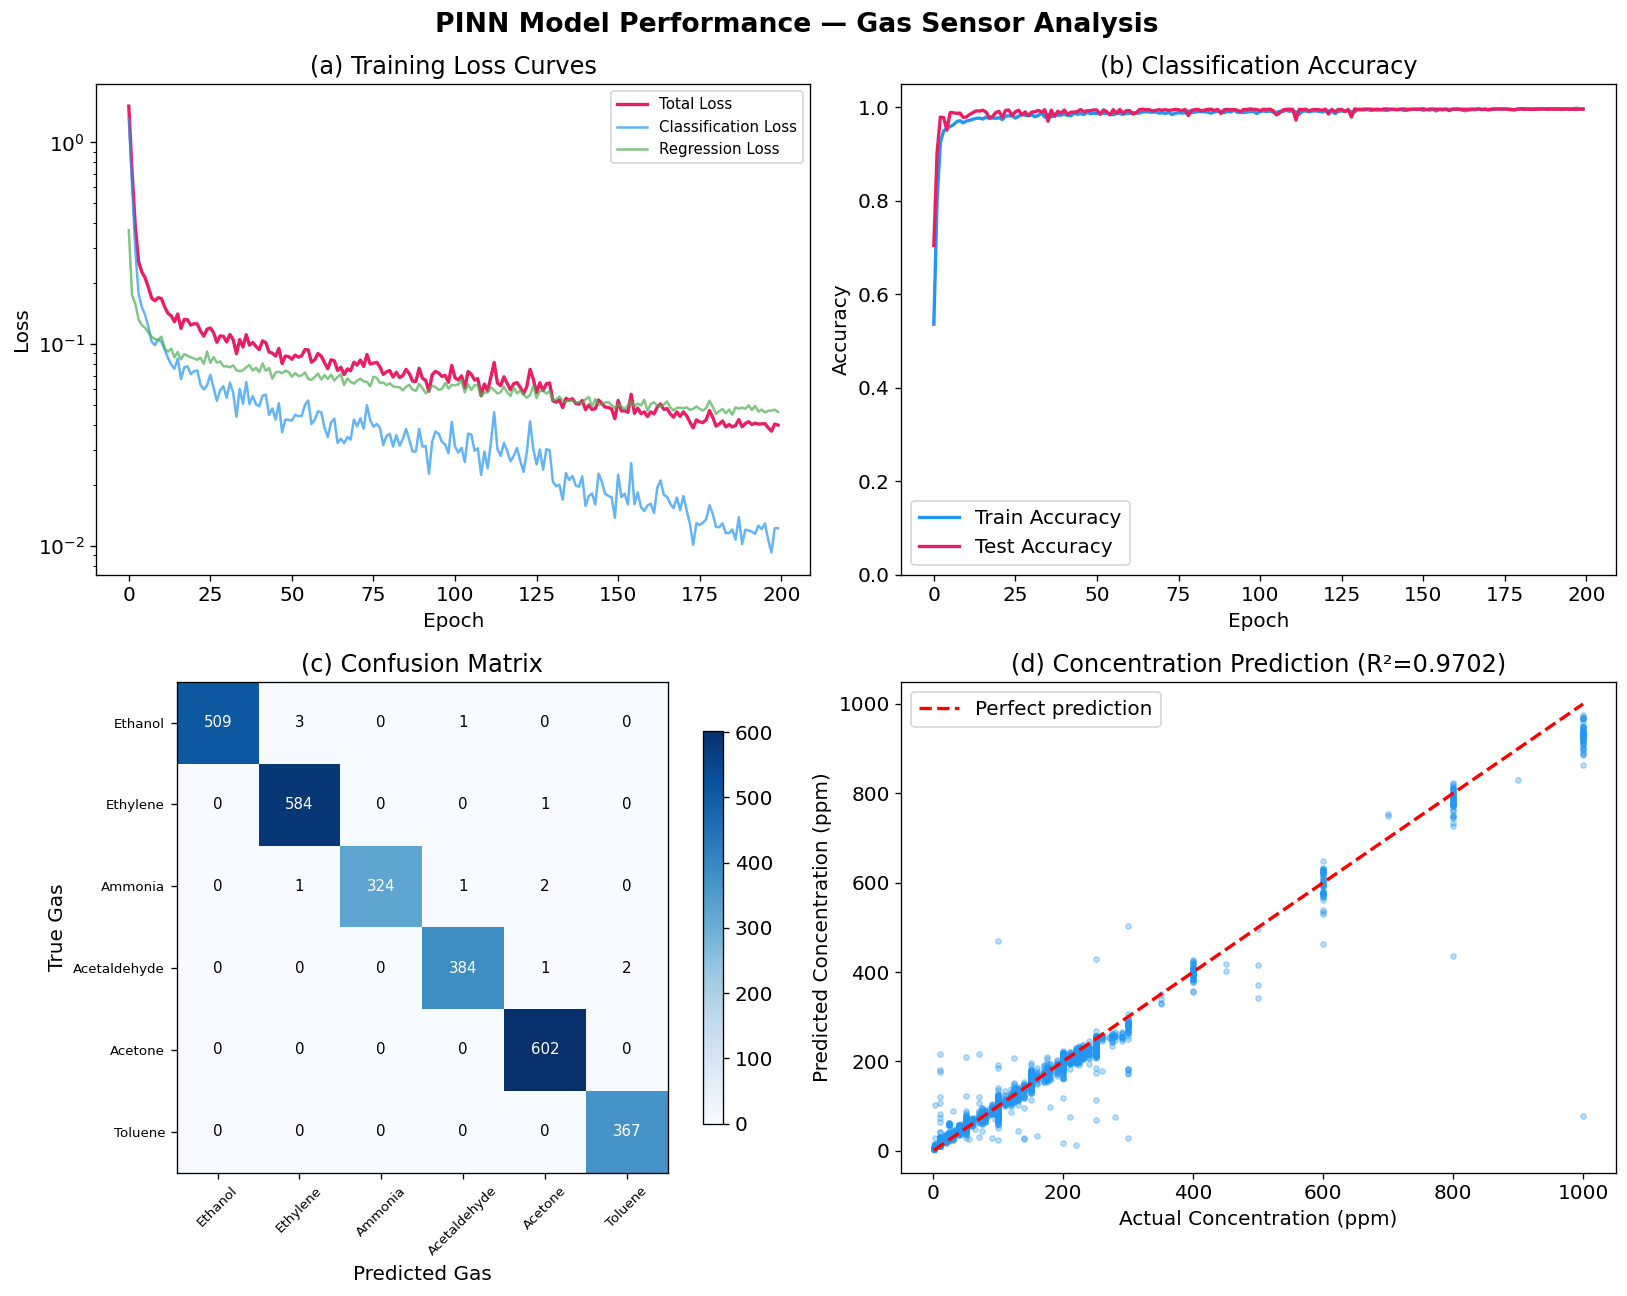


Results figure locked and loaded!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Detailed Evaluation — Classification + Regression
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import (classification_report, confusion_matrix,
                             r2_score, mean_absolute_error, mean_squared_error)

model.eval()
with torch.no_grad():
    class_logits, conc_pred, _ = model(X_test_t)
    _, class_pred = torch.max(class_logits, 1)

    class_pred_np = class_pred.numpy()
    class_true_np = yc_test_t.numpy()
    conc_pred_np = scaler_conc.inverse_transform(conc_pred.numpy().reshape(-1, 1)).flatten()
    conc_true_np = scaler_conc.inverse_transform(yr_test_t.numpy().reshape(-1, 1)).flatten()

# Classification Report
gas_labels_list = list(gas_names.values())
print("=" * 60)
print("TASK 1: GAS CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(class_true_np, class_pred_np, target_names=gas_labels_list))

# Regression Metrics
r2 = r2_score(conc_true_np, conc_pred_np)
mae = mean_absolute_error(conc_true_np, conc_pred_np)
rmse = np.sqrt(mean_squared_error(conc_true_np, conc_pred_np))

print("=" * 60)
print("TASK 2: CONCENTRATION PREDICTION")
print("=" * 60)
print(f"  R² Score:  {r2:.4f}")
print(f"  MAE:       {mae:.2f} ppm")
print(f"  RMSE:      {rmse:.2f} ppm")

# Publication-Quality Results Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('PINN Model Performance — Gas Sensor Analysis', fontsize=16, fontweight='bold')

# (a) Training curves
axes[0, 0].plot(history['total_loss'], label='Total Loss', color='#E91E63', linewidth=2)
axes[0, 0].plot(history['class_loss'], label='Classification Loss', color='#2196F3', linewidth=1.5, alpha=0.7)
axes[0, 0].plot(history['reg_loss'], label='Regression Loss', color='#4CAF50', linewidth=1.5, alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('(a) Training Loss Curves')
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_yscale('log')

# (b) Accuracy over epochs
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', color='#2196F3', linewidth=2)
axes[0, 1].plot(history['test_acc'], label='Test Accuracy', color='#E91E63', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('(b) Classification Accuracy')
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1.05])

# (c) Confusion matrix
cm = confusion_matrix(class_true_np, class_pred_np)
im = axes[1, 0].imshow(cm, cmap='Blues', interpolation='nearest')
axes[1, 0].set_title('(c) Confusion Matrix')
axes[1, 0].set_xlabel('Predicted Gas')
axes[1, 0].set_ylabel('True Gas')
axes[1, 0].set_xticks(range(6))
axes[1, 0].set_xticklabels(gas_labels_list, rotation=45, fontsize=8)
axes[1, 0].set_yticks(range(6))
axes[1, 0].set_yticklabels(gas_labels_list, fontsize=8)
for i in range(6):
    for j in range(6):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        axes[1, 0].text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)
plt.colorbar(im, ax=axes[1, 0], shrink=0.8)

# (d) Actual vs Predicted concentration
axes[1, 1].scatter(conc_true_np, conc_pred_np, alpha=0.3, s=10, color='#2196F3')
lims = [min(conc_true_np.min(), conc_pred_np.min()),
        max(conc_true_np.max(), conc_pred_np.max())]
axes[1, 1].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[1, 1].set_xlabel('Actual Concentration (ppm)')
axes[1, 1].set_ylabel('Predicted Concentration (ppm)')
axes[1, 1].set_title(f'(d) Concentration Prediction (R²={r2:.4f})')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('PINN_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nResults figure locked and loaded!")

Computing SHAP values (1-3 minutes)...
  SHAP values computed! Shape per class: (200, 128)

 SHAP Summary Plot


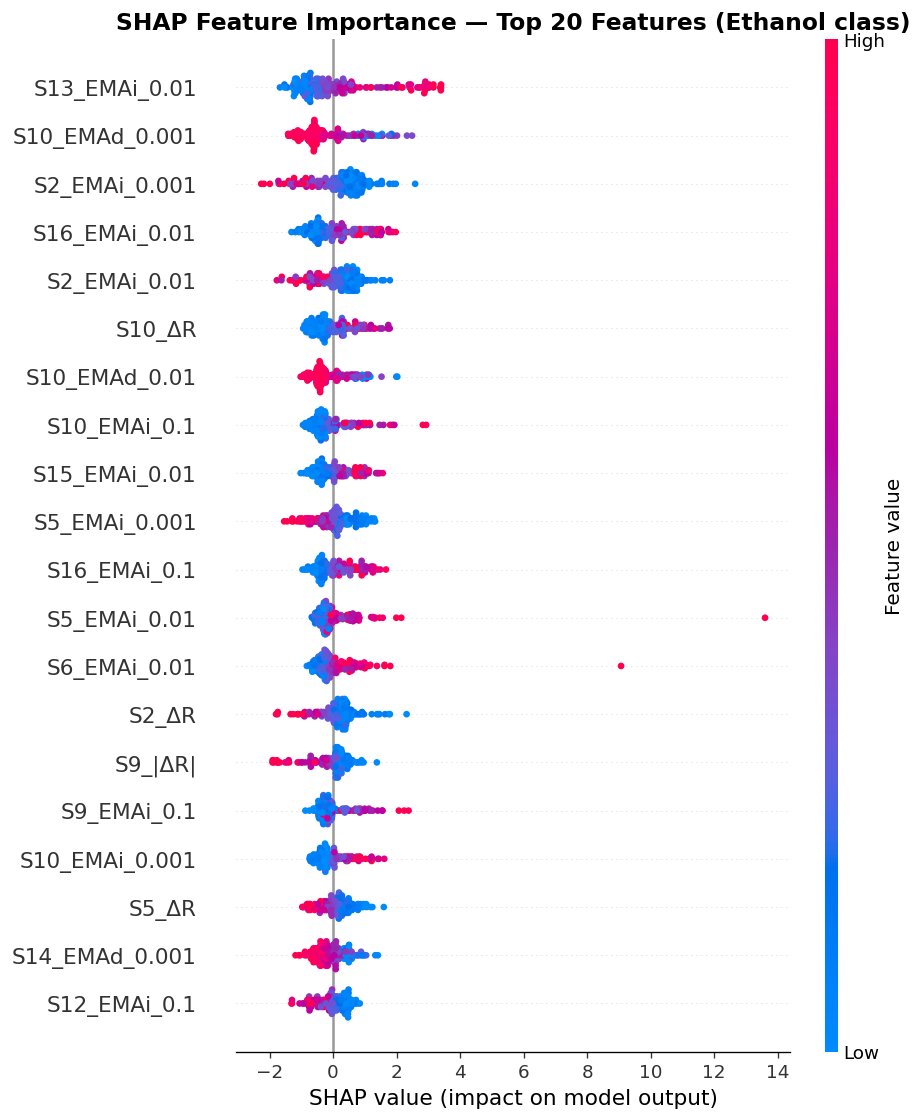


 Importance by Sensor


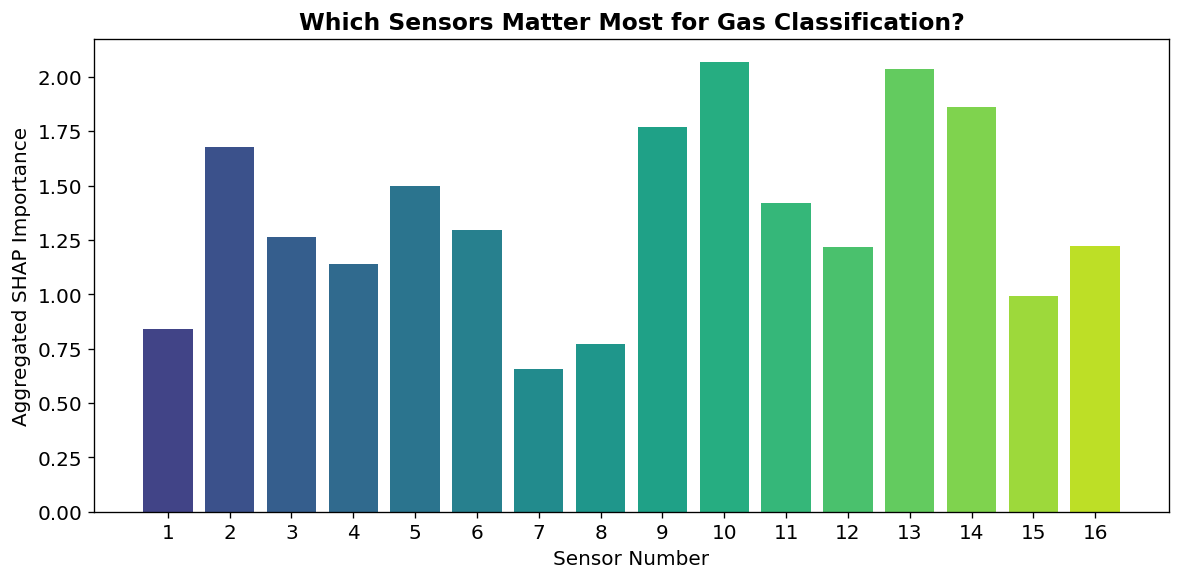


 Importance by Feature Type


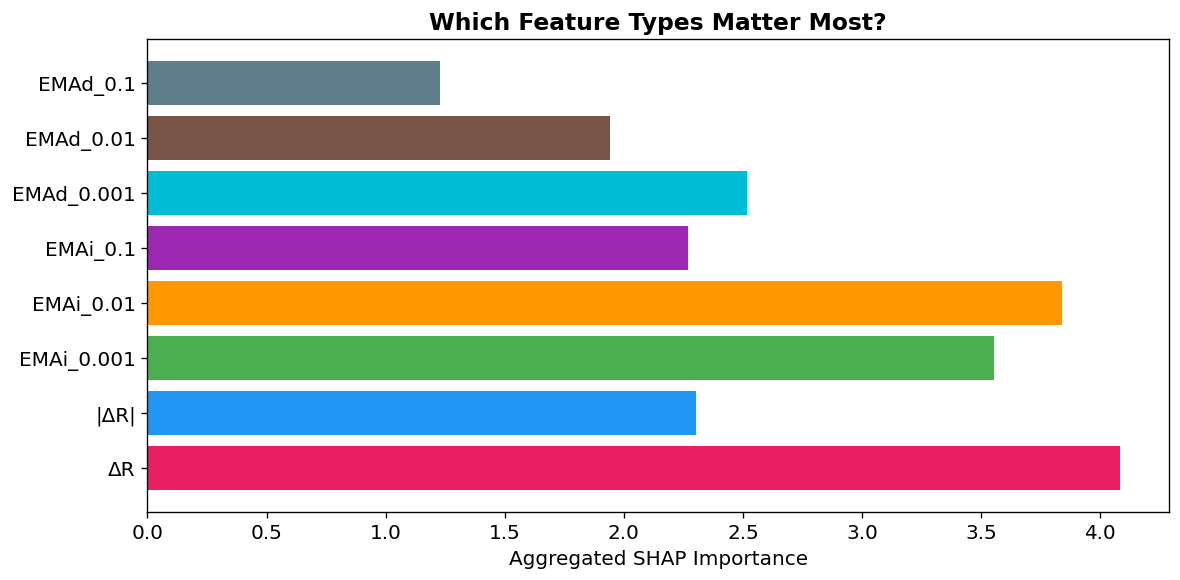


 SHAP analysis complete, 3 plots saved!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# SHAP Explainability Analysis
# ═══════════════════════════════════════════════════════════════
import shap

# Feature names for interpretability
feat_types = ['ΔR', '|ΔR|', 'EMAi_0.001', 'EMAi_0.01', 'EMAi_0.1',
              'EMAd_0.001', 'EMAd_0.01', 'EMAd_0.1']
sensor_feature_names = []
for s in range(1, 17):
    for ft in feat_types:
        sensor_feature_names.append(f'S{s}_{ft}')

# Use DeepExplainer
model.eval()
background = X_train_t[:100]
X_explain = X_test_t[:200]

# Wrapper model that returns only classification logits
class ClassifierWrapper(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.full_model = full_model
    def forward(self, x):
        logits, _, _ = self.full_model(x)
        return logits

wrapper = ClassifierWrapper(model)
wrapper.eval()

print("Computing SHAP values (1-3 minutes)...")
explainer = shap.DeepExplainer(wrapper, background)
shap_values = explainer.shap_values(X_explain)

# shap_values is a list of 6 arrays (one per gas class), each shape (200, 128)
# If it's a single array, convert to list
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print(f"  SHAP values computed! Shape per class: {shap_values[0].shape}")

# Plot 1: SHAP Summary
print("\n SHAP Summary Plot")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[0], X_explain.numpy(),
                  feature_names=sensor_feature_names,
                  max_display=20, show=False)
plt.title('SHAP Feature Importance — Top 20 Features (Ethanol class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SHAP_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Importance Aggregated by Sensor
print("\n Importance by Sensor")
# Average absolute SHAP across ALL classes
all_class_shap = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_values], axis=0)

sensor_importance = np.zeros(16)
for s in range(16):
    sensor_importance[s] = np.sum(all_class_shap[s*8 : (s+1)*8])

plt.figure(figsize=(10, 5))
colors_s = plt.cm.viridis(np.linspace(0.2, 0.9, 16))
plt.bar(range(1, 17), sensor_importance, color=colors_s)
plt.xlabel('Sensor Number', fontsize=12)
plt.ylabel('Aggregated SHAP Importance', fontsize=12)
plt.title('Which Sensors Matter Most for Gas Classification?', fontsize=14, fontweight='bold')
plt.xticks(range(1, 17))
plt.tight_layout()
plt.savefig('SHAP_sensor_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Importance by Feature Type
print("\n Importance by Feature Type")
feat_type_importance = np.zeros(8)
for ft_idx in range(8):
    indices = [s * 8 + ft_idx for s in range(16)]
    feat_type_importance[ft_idx] = np.sum(all_class_shap[indices])

colors_ft = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4', '#795548', '#607D8B']
plt.figure(figsize=(10, 5))
plt.barh(feat_types, feat_type_importance, color=colors_ft)
plt.xlabel('Aggregated SHAP Importance', fontsize=12)
plt.title('Which Feature Types Matter Most?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SHAP_feature_type_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n SHAP analysis complete, 3 plots saved!")

  Batch  1: Accuracy = 0.9600  (75 samples)
  Batch  2: Accuracy = 0.9910  (222 samples)
  Batch  3: Accuracy = 1.0000  (321 samples)
  Batch  4: Accuracy = 1.0000  (38 samples)
  Batch  5: Accuracy = 1.0000  (49 samples)
  Batch  6: Accuracy = 0.9957  (470 samples)
  Batch  7: Accuracy = 1.0000  (734 samples)
  Batch  8: Accuracy = 0.9839  (62 samples)
  Batch  9: Accuracy = 0.9875  (80 samples)
  Batch 10: Accuracy = 0.9959  (731 samples)


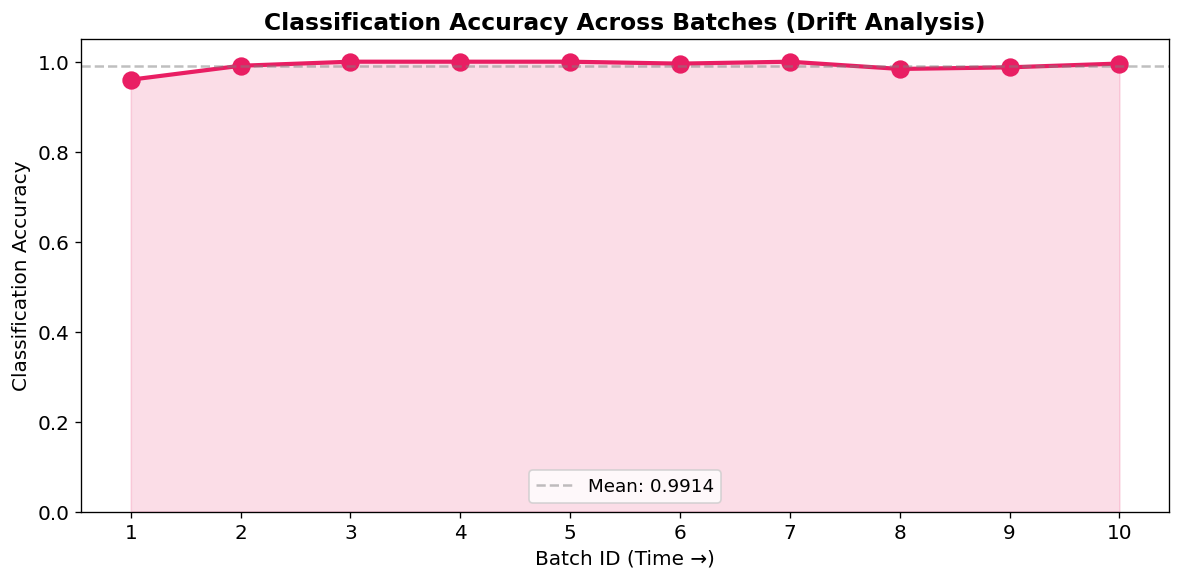


Drift analysis complete!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Drift Analysis
# ═══════════════════════════════════════════════════════════════

model.eval()
batch_accs = []

for batch_id in range(1, 11):
    mask = batch_test == batch_id
    if mask.sum() == 0:
        batch_accs.append(None)
        continue

    with torch.no_grad():
        logits, _, _ = model(X_test_t[mask])
        _, preds = torch.max(logits, 1)
        acc = (preds == yc_test_t[mask]).float().mean().item()
    batch_accs.append(acc)
    print(f"  Batch {batch_id:>2}: Accuracy = {acc:.4f}  ({mask.sum()} samples)")

# Plot drift performance
valid_batches = [(i+1, a) for i, a in enumerate(batch_accs) if a is not None]
if valid_batches:
    b_ids, b_accs = zip(*valid_batches)

    plt.figure(figsize=(10, 5))
    plt.plot(b_ids, b_accs, 'o-', color='#E91E63', linewidth=2.5, markersize=10)
    plt.fill_between(b_ids, b_accs, alpha=0.15, color='#E91E63')
    plt.axhline(y=np.mean(b_accs), color='gray', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(b_accs):.4f}')
    plt.xlabel('Batch ID (Time →)', fontsize=12)
    plt.ylabel('Classification Accuracy', fontsize=12)
    plt.title('Classification Accuracy Across Batches (Drift Analysis)', fontsize=14, fontweight='bold')
    plt.ylim([0, 1.05])
    plt.xticks(range(1, 11))
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig('drift_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nDrift analysis complete!")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Save everything & download results
# ═══════════════════════════════════════════════════════════════
import json

# Save model
torch.save(model.state_dict(), 'gas_sensor_pinn.pth')
print("Model saved: gas_sensor_pinn.pth")

# Save metrics
metrics = {
    'classification_accuracy': history['test_acc'][-1],
    'concentration_r2': r2,
    'concentration_mae_ppm': mae,
    'concentration_rmse_ppm': rmse,
    'total_samples': len(df),
    'n_features': 128,
    'n_classes': 6,
    'architecture': 'Multi-task PINN (256→128→64 shared, 32→6 classifier, 32→1 regressor)',
    'physics_constraints': [
        'Sensor response consistency (ΔR vs |ΔR|)',
        'EMA monotonicity (α ordering)',
        'Temporal drift smoothness'
    ]
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved: metrics.json")


# Download all outputs
from google.colab import files

for f_name in ['EDA_plots.png', 'PINN_results.png', 'SHAP_summary.png',
               'SHAP_sensor_importance.png', 'SHAP_feature_type_importance.png',
               'drift_analysis.png', 'gas_sensor_pinn.pth', 'metrics.json']:
    if os.path.exists(f_name):
        files.download(f_name)

print("All files downloaded!!!")

Model saved: gas_sensor_pinn.pth
Metrics saved: metrics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!!!
